# Experiment 2 — LightGBM

**Author:** Bryan  
**Data:** `train_updated.csv`, `test_updated.csv` (same as Experiment 1)  
**Model:** LightGBM (gradient boosting) — one model per target  
**Metrics:** MAE, RMSE, MAPE, R²  
**Compare to:** Experiment 1 OLS baseline (`experiment1_baseline.ipynb`)

---

## Targets (build & evaluate separately)
1. `log_total_GVA_2023` — total economic output (2023)
2. `log_gva_per_worker_2023` — productivity (GVA per worker)
3. `log_GVA_2025_predicted` — predicted future GVA (2025)

## Features (11 DAG features) 
- **Business structure:** `LU_pct_micro_2025_msoa`, `LU_pct_large_2025_msoa`, `log_enterprises_per_1k_residents_2025`
- **Economic resilience:** `turnover_diversity_1-HHI_2025_msoa`, `LU_diversity_1-HHI_2025`, `share_enterprises_kibs_2025_msoa`
- **Employment:** `emp_rate`, `full_time_share`
- **Controls:** `Urban_rura_Urban`, `log_Mid-2024 population`, `IMD_decile`

## 1. Setup & imports

In [8]:
!pip install pandas scikit-learn matplotlib lightgbm
import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 2. Load data

In [9]:
train = pd.read_csv("train_updated.csv")
test = pd.read_csv("test_updated.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nMissing values (train):", train[train.columns].isnull().sum().sum())
print("Missing values (test):", test[test.columns].isnull().sum().sum())

Train shape: (900, 21)
Test shape: (221, 21)

Missing values (train): 0
Missing values (test): 0


## 3. Define features, targets & model settings

In [10]:
FEATURES = [
    "Urban_rura_Urban",
    "LU_pct_micro_2025_msoa",
    "LU_pct_large_2025_msoa",
    "log_enterprises_per_1k_residents_2025",
    "turnover_diversity_1-HHI_2025_msoa",
    "LU_diversity_1-HHI_2025",
    "share_enterprises_kibs_2025_msoa",
    "emp_rate",
    "full_time_share",
    "log_Mid-2024 population",
    "IMD_decile",
]

TARGETS = [
    "log_total_GVA_2023",
    "log_gva_per_worker_2023",
    "log_GVA_2025_predicted",
]

# Fixed hyperparameters (no tuning — mirrors Exp 1 "no tuning" approach)
LGBM_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

# OLS baseline R² from Experiment 1 (for comparison)
OLS_R2 = {
    "log_total_GVA_2023": 0.5548,
    "log_gva_per_worker_2023": 0.1508,
    "log_GVA_2025_predicted": 0.5684,
}

print("Features:", len(FEATURES), "| Targets:", len(TARGETS))
print("LGBM params:", LGBM_PARAMS)

Features: 11 | Targets: 3
LGBM params: {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'verbose': -1}


## 4. Evaluation helper

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def evaluate_regressor(model, X_test, y_test):
    y_pred = model.predict(X_test)  # predict on held-out test set
    return {
    "MAE": mean_absolute_error(y_test, y_pred),# average absolute error
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)), # root mean squared error (√MSE); penalises large errors more
    "MAPE (%)": mape(y_test, y_pred), # average error as % of actual values
    "R²": r2_score(y_test, y_pred),# share of variance explained (higher is better)
}, y_pred  # also return predictions for plots in 6


---
## 5. Train & evaluate — all 3 targets

**Goal:** Loop over `TARGETS`, train one LightGBM per target, evaluate on test, build `results_df`.

**Reference:** Exp 1 §8 summary loop — same idea, but use `LGBMRegressor` + your §4 helper.

---



1. **Split** → `X_train`, `y_train`, `X_test`, `y_test` (same as Exp 1)
2. **Create model** → `LGBMRegressor(**LGBM_PARAMS)`  *(not LinearRegression)*
3. **Fit** → `model.fit(X_train, y_train)`
4. **Evaluate** → `metrics, y_pred = evaluate_regressor(model, X_test, y_test)`
5. **Compare to OLS** → add `Target`, `OLS_R2[target]`, and `ΔR² vs OLS` to `metrics`
6. **Save** → append to `results`, store in `models` and `predictions`

---

### Before the loop — create 3 empty containers

| Name | Type | Stores |
|---|---|---|
| `results` | list | metric dicts |
| `models` | dict | trained model per target |
| `predictions` | dict | `(y_test, y_pred)` per target |

---

### After the loop — build the table

- `results_df = pd.DataFrame(results)`
- `display(results_df[cols].round(4))`

---

**Write your code in the cell below.**

In [23]:
results = []
models = {}
predictions = {}

for target in TARGETS:
    X_train = train[FEATURES]
    y_train = train[target]
    X_test = test[FEATURES]
    y_test = test[target]

    model = LGBMRegressor(**LGBM_PARAMS)
    model.fit(X_train, y_train)

    metrics, y_pred = evaluate_regressor(model, X_test, y_test)
    metrics["Target"] = target
    metrics["R² OLS (Exp 1)"] = OLS_R2[target]
    metrics["ΔR² vs OLS"] = metrics["R²"] - OLS_R2[target]

    results.append(metrics)
    models[target] = model
    predictions[target] = (y_test, y_pred)

    print(f"\n=== {target} ===")
    for k, v in metrics.items():
        if k != "Target":
            print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

results_df = pd.DataFrame(results)
cols = ["Target", "MAE", "RMSE", "MAPE (%)", "R²", "R² OLS (Exp 1)", "ΔR² vs OLS"]
display(results_df[cols].round(4))



=== log_total_GVA_2023 ===
  MAE: 0.4506
  RMSE: 0.7292
  MAPE (%): 12.2401
  R²: 0.5627
  R² OLS (Exp 1): 0.5548
  ΔR² vs OLS: 0.0079

=== log_gva_per_worker_2023 ===
  MAE: 0.4654
  RMSE: 0.7331
  MAPE (%): 4.1133
  R²: 0.0978
  R² OLS (Exp 1): 0.1508
  ΔR² vs OLS: -0.0530

=== log_GVA_2025_predicted ===
  MAE: 0.4653
  RMSE: 0.7281
  MAPE (%): 13.1114
  R²: 0.5835
  R² OLS (Exp 1): 0.5684
  ΔR² vs OLS: 0.0151


,Target,MAE,RMSE,MAPE (%),R²,R² OLS (Exp 1),ΔR² vs OLS
0,log_total_GVA_2023,0.4506,0.7292,12.2401,0.5627,0.5548,0.0079
1,log_gva_per_worker_2023,0.4654,0.7331,4.1133,0.0978,0.1508,-0.0530
2,log_GVA_2025_predicted,0.4653,0.7281,13.1114,0.5835,0.5684,0.0151


---
## 6. Predicted vs actual plots

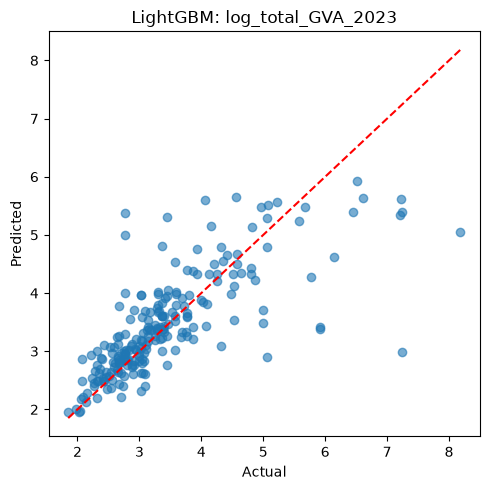

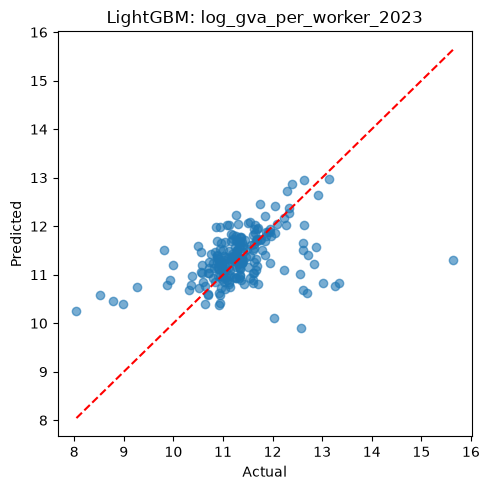

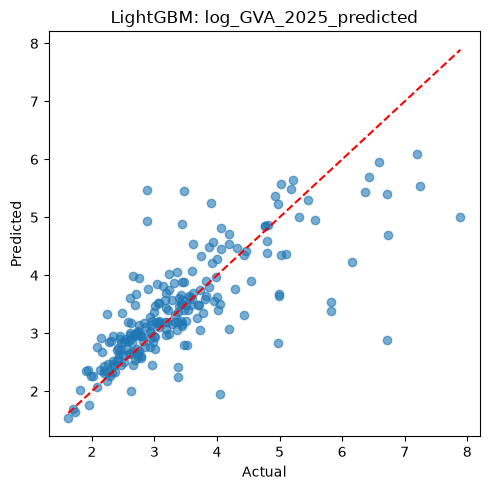

In [13]:
for target in TARGETS:
    y_test, y_pred = predictions[target]

    plt.figure(figsize=(5, 5))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"LightGBM: {target}")
    plt.tight_layout()
    plt.show()

---
## 7. Feature importance (gain)

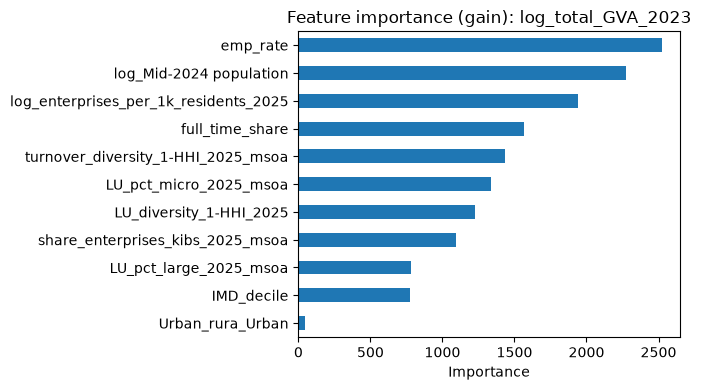

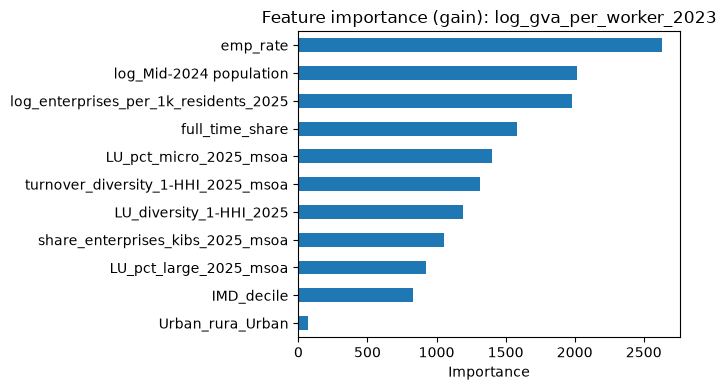

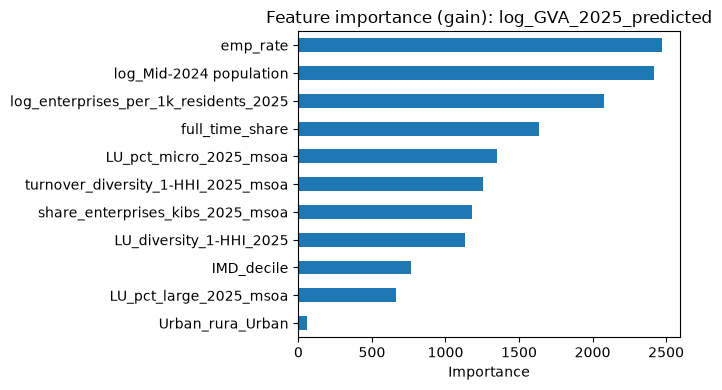

In [14]:
for target in TARGETS:
    # Build a named Series: feature → importance score from the trained model
    imp = pd.Series(
        models[target].feature_importances_,  # LightGBM gain scores (one per feature)
        index=FEATURES,  # label each score with its feature name
    ).sort_values(ascending=True)  # low → high (barh reads bottom-to-top)

    plt.figure(figsize=(7, 4))
    imp.plot(kind="barh")
    plt.title(f"Feature importance (gain): {target}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

---
## 8. OLS vs LightGBM comparison table

In [24]:
comparison = results_df[["Target", "R²", "R² OLS (Exp 1)", "ΔR² vs OLS"]].copy()
comparison["Preferred model"] = comparison.apply(
    # lambda: small one-line function, no need for def
    # r: one row of the dataframe
    # r["ΔR² vs OLS"] > 0: if LightGBM R² is higher than OLS
    # "LightGBM": label that row as LightGBM
    # else "OLS": otherwise label as OLS
    lambda r: "LightGBM" if r["ΔR² vs OLS"] > 0 else "OLS",
    axis=1,  # run row-by-row (one label per target)
)
display(comparison.round(4))

,Target,R²,R² OLS (Exp 1),ΔR² vs OLS,Preferred model
0,log_total_GVA_2023,0.5627,0.5548,0.0079,LightGBM
1,log_gva_per_worker_2023,0.0978,0.1508,-0.0530,OLS
2,log_GVA_2025_predicted,0.5835,0.5684,0.0151,LightGBM


---
## 9. Swindon portability check

In [16]:
swindon_test = test[test["is_swindon"] == "Swindon"]
other_test = test[test["is_swindon"] == "Others"]

portability = []

for target in TARGETS:
    model = models[target]

    for group_name, subset in [("Swindon", swindon_test), ("Others", other_test)]:
        y_true = subset[target]
        y_pred = model.predict(subset[FEATURES])
        portability.append({
            "Target": target,
            "Group": group_name,
            "n": len(subset),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAPE (%)": mape(y_true, y_pred),
            "R²": r2_score(y_true, y_pred),
        })

portability_df = pd.DataFrame(portability)
display(portability_df.round(4))

,Target,Group,n,MAE,RMSE,MAPE (%),R²
0,log_total_GVA_2023,Swindon,18,0.3004,0.4247,9.3842,0.7311
1,log_total_GVA_2023,Others,203,0.4639,0.7502,12.4933,0.5441
2,log_gva_per_worker_2023,Swindon,18,0.3210,0.4461,2.7238,0.4334
3,log_gva_per_worker_2023,Others,203,0.4782,0.7533,4.2365,0.0678
4,log_GVA_2025_predicted,Swindon,18,0.3836,0.5318,12.7576,0.6436
5,log_GVA_2025_predicted,Others,203,0.4726,0.7430,13.1428,0.5675


---
## 10. Live vs work robustness (non-hub LSOAs)

Re-evaluate Model 1 (`log_total_GVA_2023`) excluding commuter hubs (`emp_rate > 1`).

In [17]:
target = "log_total_GVA_2023"
train_nonhub = train[train["emp_rate"] <= 1]
test_nonhub = test[test["emp_rate"] <= 1]

model_nh = LGBMRegressor(**LGBM_PARAMS)
model_nh.fit(train_nonhub[FEATURES], train_nonhub[target])
y_pred_nh = model_nh.predict(test_nonhub[FEATURES])
y_test_nh = test_nonhub[target]

print(f"Non-hub train/test: {len(train_nonhub)} / {len(test_nonhub)}")
print(f"R² (LightGBM, non-hub): {r2_score(y_test_nh, y_pred_nh):.4f}")
print(f"R² (OLS, non-hub, Exp 1): 0.4084")

Non-hub train/test: 792 / 199
R² (LightGBM, non-hub): 0.4016
R² (OLS, non-hub, Exp 1): 0.4084
